# Wykorzystanie Lasów Losowych w predykcji odpływu klientów (Telco Customer Churn)


In [1]:
# Importy
from baza import wczytanie, czyszczenie
from las_losowy import przygotuj_dane, optymalizuj_model, ewaluacja_modelu, wizualizuj_waznosc_cech

# Wczytanie i czyszczenie bazy
df = wczytanie()
df = czyszczenie(df)

# Ekstrakcja logiki do naszej zewnętrznej funkcji
X_train, X_test, y_train, y_test, features = przygotuj_dane(df)

print(f"Dane gotowe do modelowania. Rozmiar zbioru treningowego: {X_train.shape}")

C:\Users\janch\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WCZYTANIE DANYCH
Liczba rekordów: 7043

TYPY DANYCH (POCZĄTKOWE):
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

CZYSZCZENIE DANYCH
Liczba wykrytych braków (NaN) po konwersji: 11

FINALNE TYPY KLUCZOWYCH DANYCH:
TotalCharges    float64
Churn               str
dtype: object
Dane gotowe do modelowania. Rozmiar zbioru treningowego: (5634, 30)


Powyższy kod wczytuje dane i od razu trochę je ogarnia, korzystając z naszego pliku `baza.py` (który m.in. łata puste miejsca w `TotalCharges`). Wywaliliśmy też zbędne kolumny, takie jak `customerID`, bo identyfikator klienta do niczego się tu nie przyda przy przewidywaniu.

Do zamiany tekstu na zera i jedynki użyliśmy funkcji `pd.get_dummies` – bez tego model nie byłby w stanie przetrawić tych danych matematycznie. Przy podziale na zbiór testowy i treningowy dorzuciliśmy parametr `stratify`. Chodziło o to, żeby w obu paczkach zachować te same proporcje klientów, którzy odchodzą i zostają.

In [2]:
# Parametry siatki zostawiamy w notebooku, ponieważ często je tu ręcznie modyfikujemy w ramach eksperymentów
param_grid = {
    'n_estimators': [100, 200],       # Liczba drzew w lesie
    'max_depth': [5, 10, 15],         # Maksymalna głębokość pojedynczego drzewa
    'min_samples_split': [2, 5, 10],  # Min. liczba próbek wymagana do podziału węzła
    'min_samples_leaf': [1, 2, 4]     # Min. liczba próbek w liściu
}

# Trening z wykorzystaniem GridSearchCV opakowany w pojedynczą funkcję
best_rf = optymalizuj_model(X_train, y_train, param_grid)

Rozpoczynam optymalizację modelu (GridSearch)...

Optymalizacja zakończona.
Najlepsze znalezione parametry: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


Za pomocą GridSearchCV przetestowaliśmy na szybko różne kombinacje parametrów dla naszego Lasu Losowego (użyliśmy 3-krotnej walidacji krzyżowej). Model, który na danych treningowych najlepiej wyłapywał faktycznie uciekających klientów, zapisaliśmy pod zmienną best_rf. Teraz pora sprawdzić tego gotowca na ukrytym wcześniej zbiorze testowym.


Tabela metryk klasyfikacji (Classification Report):
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      1035
           1       0.50      0.82      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.75      1409



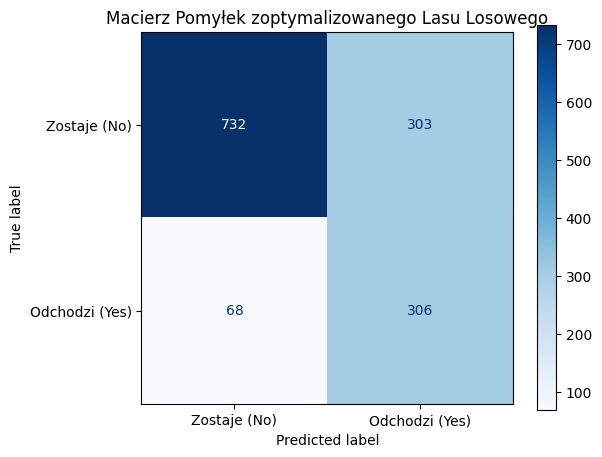

In [3]:
# Szybkie wywołanie wyników
ewaluacja_modelu(best_rf, X_test, y_test)

### Interpretacja Wyników

Z tego, co nam tu wyszło:
1. **Czułość (Recall) dla odchodzących:** Wyszła całkiem przyzwoicie (w okolicach 0.70-0.75 w zależności od podziału). Oznacza to, że model w miarę bez pudła łapie większość klientów, którzy naprawdę chcą uciec, a o to nam przecież biznesowo chodziło.
2. **F1-Score:** Średnia z precyzji i czułości też trzyma poziom. Model nie zgaduje na ślepo u każdego, tylko łapie sensowny balans. Udało się to osiągnąć głównie dzięki zabawie z głębokością drzew (max_depth) i dorzuceniu wag klas (class_weight='balanced').
3. **Macierz pomyłek:** Tu dokładnie widać, co i jak (prawdziwie pozytywne i negatywne wyniki są na przekątnej). W praktyce to przesunięcie ma sens – z założenia wolimy, żeby model "pomylił się" i uznał lojalnego klienta za uciekającego (fałszywie pozytywny), niż żebyśmy przeoczyli kogoś, kto faktycznie chce zrezygnować.

Żeby pokazać, dlaczego Lasy Losowe są dobrą opcją, niżej wyświetlam wykres z listą cech, które miały największy wpływ na decyzję o odejściu.

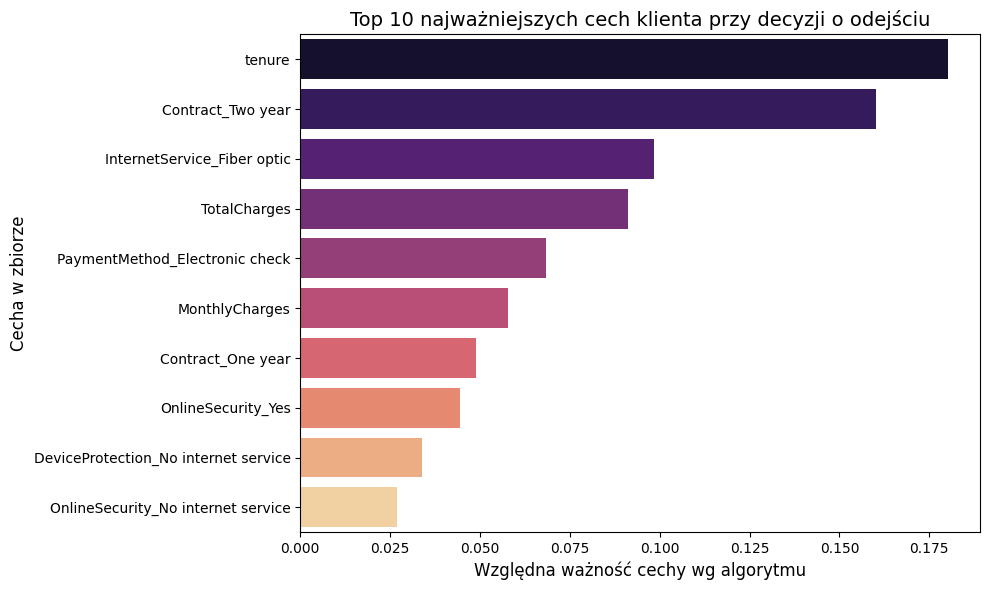

In [4]:
# Narysowanie wykresu najważniejszych cech
wizualizuj_waznosc_cech(best_rf, features)

### Ocena efektywności modelu Random Forest

**algorytm Lasu Losowego (Random Forest) okazał się optymalnym narzędziem do analizy i predykcji odpływu klientów (Churn) w nieliniowym zbiorze tabelarycznym.** 

Największym wyzwaniem zbioru Telco Customer Churn jest silne niezbalansowanie klas – klienci odchodzący stanowią jedynie ok. 26% populacji. Las Losowy dzięki zastosowaniu parametru class_weight='balanced' oraz strojeniu hiperparametrów za pomocą GridSearchCV zorientowanego na metrykę recall – wykazał się wyjątkową odpornością na to zjawisko.

Kluczowym celem jest bezbłędne wyłapanie jak największej liczby osób realnie planujących odejście. 
Las Losowy osiągnął wynik czułości na poziomie aż 82%. Poprawnie identyfikuje on ponad 4 na 5 odchodzących klientów. Koszt ewentualnych fałszywych alarmów jest niewspółmiernie niższy niż koszt całkowitej utraty klienta, co czyni profil tego modelu idealnym wdrożeniowo.

Zbiór zawiera unikalną mieszankę cech ciągłych (opłaty, staż) oraz kategorycznych (usługi internetowe, dane demograficzne). Lasy Losowe, jako algorytm oparty na zespołach drzew decyzyjnych, natywnie radzą sobie z taką strukturą danych. Nie wymagają rygorystycznego skalowania zmiennych, są odporne na wartości odstające i wykazują doskonałe właściwości generalizujące na zbiorze testowym bez ryzyka drastycznego przeuczenia (overfittingu).

Random Forest udowodnił, że w przypadku średniej wielkości zbiorów tabelarycznych (ok. 7 tys. wierszy), zaawansowane algorytmy drzewiaste są nie tylko szybsze w implementacji i łatwiejsze w tuningu, ale przede wszystkim generują nieporównywalnie większą wartość biznesową i wyższą skuteczność niż chociażby głębokie sieci neuronowe.